## **Detecção de Objetos com Detectron2**

Neste notebook, utilizamos a biblioteca Detectron2 para realizar a detecção e segmentação de objetos em uma imagem. O código a seguir permite visualizar os resultados das predições de um modelo Mask R-CNN, utilizando o visualizador do Detectron2.

O modelo é carregado com pesos pré-treinados no dataset COCO e a imagem de entrada é processada para identificar e segmentar instâncias de objetos. Através da visualização, podemos observar as caixas delimitadoras, as máscaras de segmentação e as classificações de cada objeto detectado.

In [ ]:
# Instalar dependências e Detectron2
!pip install -U torch torchvision cython
# Instala ou atualiza o pacote PyTorch (torch), torchvision (biblioteca para visão computacional)
# e cython (utilizado para compilar e acelerar código C para Python).

!pip install -U 'git+https://github.com/facebookresearch/fvcore.git' 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
# Instala ou atualiza o pacote fvcore (fornecido pela Facebook AI Research)
# e a COCO API (uma biblioteca para trabalhar com o conjunto de dados COCO, usada em tarefas de visão computacional).
# Ambos são necessários para usar o Detectron2, que é uma biblioteca para detecção de objetos e segmentação.

# Importação de bibliotecas
import torch, torchvision
# Importa o PyTorch (torch) que fornece funcionalidades para redes neurais e aprendizado profundo.
# Importa o torchvision, que contém ferramentas e modelos prontos para tarefas de visão computacional, como detecção de objetos.

# Verificação da versão do PyTorch
torch.__version__
# Exibe a versão atual do PyTorch instalada, o que pode ser útil para verificar se a instalação foi bem-sucedida.


  Cloning https://github.com/facebookresearch/fvcore.git to /tmp/pip-req-build-urnda1ml
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/fvcore.git /tmp/pip-req-build-urnda1ml
  Resolved https://github.com/facebookresearch/fvcore.git to commit a491d5b9a06746f387aca2f1f9c7c7f28e20bef9
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/cocodataset/cocoapi.git to /tmp/pip-req-build-nk5l_n9f
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/cocoapi.git /tmp/pip-req-build-nk5l_n9f
  Resolved https://github.com/cocodataset/cocoapi.git to commit 8c9bcc3cf640524c4c20a9c40e89cb6a2f2fa0e9
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.6-py3-none-any.whl size=65670 sha256=6848bc5c30140ea1930c018545821898d06e232d69d413fb6c41825accdc7f08
  Sto

'2.5.1+cu121'

In [ ]:
# Clonando o repositório do Detectron2
!git clone https://github.com/facebookresearch/detectron2 detectron2_repo
# Usa o comando `git clone` para clonar o repositório oficial do Detectron2 do GitHub.
# O repositório será baixado para uma pasta chamada `detectron2_repo` no ambiente local (neste caso, no Google Colab).
# O Detectron2 é uma biblioteca de código aberto da Facebook AI Research (FAIR) para detecção de objetos, segmentação e outras tarefas de visão computacional.

# Instalando o Detectron2 a partir do repositório clonado
!pip install -e detectron2_repo
# Instala o Detectron2 de forma "editable" a partir do diretório local (o repositório clonado).
# A opção `-e` no `pip install` indica uma instalação "editable", ou seja, qualquer alteração no código-fonte do Detectron2 será refletida automaticamente, sem a necessidade de reinstalar.
# Isso é útil durante o desenvolvimento ou quando você deseja experimentar mudanças no código.


Cloning into 'detectron2_repo'...
remote: Enumerating objects: 15819, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 15819 (delta 31), reused 43 (delta 17), pack-reused 15743 (from 1)
Receiving objects: 100% (15819/15819), 6.39 MiB | 12.49 MiB/s, done.
Resolving deltas: 100% (11523/11523), done.
Obtaining file:///content/detectron2_repo
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.8/427.8 kB 23.6 MB/s

In [ ]:
# Importando o módulo principal do Detectron2
import detectron2
# O comando importa o módulo principal da biblioteca Detectron2. Isso permite usar as funcionalidades da biblioteca para tarefas de visão computacional, como detecção de objetos e segmentação.

# Importando e configurando o logger do Detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
# A função `setup_logger()` é chamada para configurar o sistema de logging do Detectron2.
# Isso garante que mensagens de log e erros sejam exibidos corretamente durante a execução do código.
# O `setup_logger()` ajuda a organizar e melhorar a visualização das mensagens de log durante o uso do Detectron2.

# Importando bibliotecas adicionais necessárias para o processamento de imagens e visualização
import numpy as np
# A biblioteca `numpy` é importada para manipulação de arrays e operações matemáticas, uma das ferramentas fundamentais para trabalhar com dados numéricos em Python.

import cv2
# A biblioteca `cv2` (OpenCV) é importada para operações de visão computacional, como manipulação e exibição de imagens.

import random
# A biblioteca `random` é importada para gerar números aleatórios, que podem ser úteis em várias operações, como seleção aleatória de imagens ou augumentação de dados.

from google.colab.patches import cv2_imshow
# O `cv2_imshow` é importado especificamente para exibir imagens em ambientes como o Google Colab.
# O OpenCV (`cv2`) tem uma função `imshow` para mostrar imagens, mas no Colab a função correta é `cv2_imshow`, que lida melhor com a exibição de imagens dentro do notebook.

# Importando as classes necessárias do Detectron2
from detectron2.engine import DefaultPredictor
# O `DefaultPredictor` é importado para realizar predições com um modelo treinado no Detectron2.
# Ele é uma interface fácil de usar para fazer inferência com modelos Detectron2.

from detectron2.config import get_cfg
# O `get_cfg()` é importado para criar e manipular o objeto de configuração do Detectron2.
# Essa função ajuda a definir os parâmetros de configuração para a criação do modelo, como tipo de modelo, pré-processamento de dados, etc.

from detectron2.utils.visualizer import Visualizer
# O `Visualizer` é importado para facilitar a visualização dos resultados de inferência, como desenhar caixas delimitadoras ou máscaras de segmentação nas imagens.

from detectron2.data import MetadataCatalog
# O `MetadataCatalog` é importado para acessar informações sobre o conjunto de dados, como rótulos de classes e metadados associados às imagens.
# Isso é importante para garantir que os resultados da inferência sejam visualizados corretamente com as informações associadas às classes detectadas.


--2024-12-12 23:11:10--  https://img.freepik.com/free-photo/anxiety-inducing-imagery-with-angst-feelings-unease_23-2150981971.jpg
Resolving img.freepik.com (img.freepik.com)... 23.219.78.79, 23.219.78.71, 2600:1409:3c00:9::172c:af49, ...
Connecting to img.freepik.com (img.freepik.com)|23.219.78.79|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72133 (70K) [image/jpeg]
Saving to: ‘input.jpg’

input.jpg           100%[===================>]  70.44K   200KB/s    in 0.4s    

2024-12-12 23:11:11 (200 KB/s) - ‘input.jpg’ saved [72133/72133]



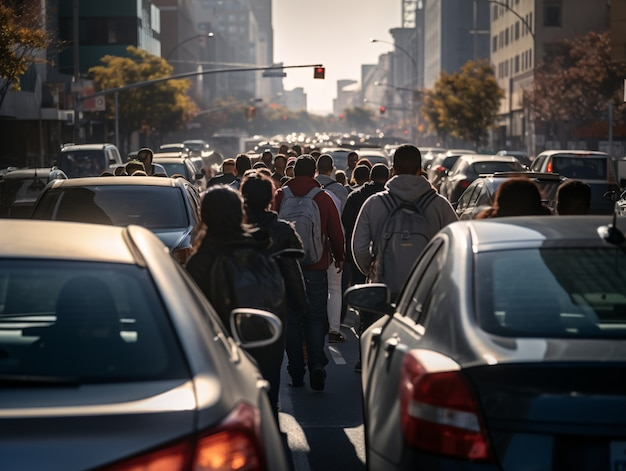

In [ ]:
# Baixando uma imagem para teste usando o comando wget
!wget https://img.freepik.com/free-photo/anxiety-inducing-imagery-with-angst-feelings-unease_23-2150981971.jpg -O input.jpg
# O comando `wget` é utilizado para baixar um arquivo da internet.
# A URL fornecida aponta para uma imagem hospedada no site Freepik.
# A opção `-O input.jpg` especifica que o arquivo será salvo com o nome `input.jpg` no diretório atual do ambiente de execução.

# Lendo a imagem usando a função imread do OpenCV
im = cv2.imread("./input.jpg")
# A função `cv2.imread()` do OpenCV é usada para carregar a imagem baixada para o ambiente de execução.
# Ela recebe o caminho do arquivo como argumento e retorna a imagem em formato NumPy (um array multidimensional).
# A variável `im` armazena a imagem carregada para ser manipulada ou exibida posteriormente.

# Exibindo a imagem no notebook com cv2_imshow (adaptado para o Colab)
cv2_imshow(im)
# A função `cv2_imshow()` é uma versão adaptada da função `imshow()` do OpenCV, que é usada para exibir imagens em notebooks Jupyter ou Google Colab.
# O `cv2_imshow()` é necessário, pois o `imshow()` padrão do OpenCV não funciona corretamente no Colab.
# A função exibe a imagem carregada anteriormente na variável `im` diretamente no ambiente do notebook.


In [ ]:
# Obtendo as configurações padrão do Detectron2
cfg = get_cfg()
# A função `get_cfg()` do Detectron2 cria um objeto de configuração vazio que contém as configurações padrão para o modelo.
# Este objeto `cfg` será posteriormente configurado para usar o modelo Mask R-CNN e as configurações específicas.

# Carregando um arquivo de configuração YAML do Detectron2
cfg.merge_from_file("./detectron2_repo/configs/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
# O método `merge_from_file()` carrega um arquivo YAML que contém as configurações específicas para o modelo Mask R-CNN.
# O caminho do arquivo YAML especificado aqui é o arquivo de configuração do modelo Mask R-CNN com backbone ResNet-50 e FPN, ajustado para 3 iterações de treinamento.
# As configurações deste arquivo sobrescrevem as configurações padrão do `cfg` carregado na etapa anterior.

# Ajustando o limiar de confiança para a predição
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
# Aqui, o limiar de confiança (threshold) para as previsões é ajustado.
# Isso significa que o modelo só considerará como objetos as detecções que tenham uma pontuação de confiança maior que 0.5.
# O valor padrão de `SCORE_THRESH_TEST` é 0.05, mas é ajustado aqui para 0.5, para filtrar predições com pontuações baixas.

# Definindo o caminho para os pesos do modelo pré-treinado
cfg.MODEL.WEIGHTS = "detectron2://COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl"
# O parâmetro `MODEL.WEIGHTS` é configurado para apontar para o arquivo de pesos do modelo Mask R-CNN treinado no dataset COCO.
# Este arquivo contém os pesos do modelo pré-treinado, que serão carregados durante a inicialização do modelo.
# O link `detectron2://` é usado para carregar pesos diretamente do repositório do Detectron2.

# Inicializando o preditor com as configurações definidas
predictor = DefaultPredictor(cfg)
# O `DefaultPredictor` é uma classe do Detectron2 usada para fazer previsões com base nas configurações passadas no objeto `cfg`.
# O preditor é inicializado com as configurações do modelo, incluindo os pesos pré-treinados e as configurações ajustadas.

# Fazendo a previsão sobre a imagem de entrada
outputs = predictor(im)
# O método `predictor(im)` realiza a inferência (predição) sobre a imagem `im`.
# A variável `outputs` conterá as predições feitas pelo modelo, incluindo os resultados de segmentação, as caixas delimitadoras (bounding boxes) e as máscaras para os objetos detectados na imagem.


[12/12 23:11:18 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from detectron2://COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


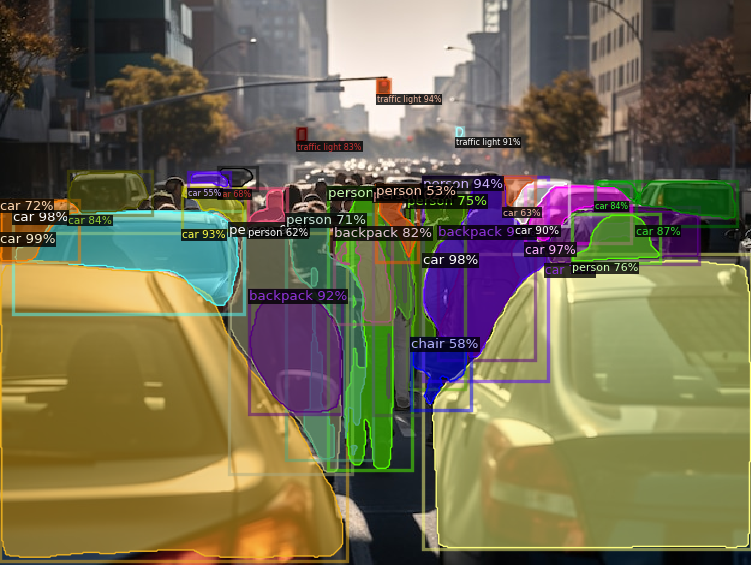

In [ ]:
# Inicializando o visualizador com a imagem e os metadados do dataset
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
# O `Visualizer` é uma classe do Detectron2 usada para desenhar as predições (como caixas delimitadoras e máscaras) sobre a imagem.
# A imagem `im` precisa ser convertida de BGR (formato padrão do OpenCV) para RGB (formato usado pelo Visualizer), e é feito com `im[:, :, ::-1]`.
# `MetadataCatalog.get(cfg.DATASETS.TRAIN[0])` obtém os metadados do dataset de treinamento (neste caso, o primeiro dataset listado em `cfg.DATASETS.TRAIN`).
# Esses metadados incluem informações sobre as classes dos objetos detectados, que serão usadas para anotar as predições na imagem.
# O parâmetro `scale=1.2` define o fator de escala para redimensionar a imagem visualizada, tornando-a 1.2 vezes maior do que o tamanho original.

# Desenhando as predições na imagem
v = v.draw_instance_predictions(outputs["instances"].to("cpu"))
# O método `draw_instance_predictions()` desenha as predições feitas pelo modelo sobre a imagem.
# A variável `outputs["instances"]` contém as instâncias detectadas, e `.to("cpu")` move as instâncias para a CPU, pois o modelo pode estar operando na GPU.
# Este método desenha caixas delimitadoras, máscaras e rótulos de classe sobre os objetos detectados na imagem.

# Exibindo a imagem com as predições desenhadas
cv2_imshow(v.get_image()[:, :, ::-1])
# `v.get_image()` retorna a imagem com as predições desenhadas.
# Assim como antes, é feito um índice `[:, :, ::-1]` para converter a imagem de volta de RGB para BGR, pois o OpenCV usa o formato BGR para exibição.
# `cv2_imshow()` é uma função do Google Colab, que exibe imagens utilizando o OpenCV. Este comando exibe a imagem com as predições feitas pelo modelo.
